In [5]:
!pip install pmdarima --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 62.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
data = pd.read_csv('/content/drive/MyDrive/TSA_Project_CMI/household_power_consumption.txt', sep=';',
                  parse_dates={'dt' : ['Date', 'Time']}, infer_datetime_format=True,
                 low_memory=False, na_values=['nan','?'],index_col='dt')

/tmp/ipython-input-3055179447.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  data = pd.read_csv('/content/drive/MyDrive/TSA_Project_CMI/household_power_consumption.txt', sep=';',
/tmp/ipython-input-3055179447.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv('/content/drive/MyDrive/TSA_Project_CMI/household_power_consumption.txt', sep=';',
/tmp/ipython-input-3055179447.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data = pd.read_csv('/content/drive/MyDrive/TSA_Project_CMI/household_power_consumpti

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/TSA_Project_CMI/household_power_consumption.txt', sep=';',
                  parse_dates={'dt' : ['Date', 'Time']}, infer_datetime_format=True,
                 low_memory=False, na_values=['nan','?'],index_col='dt')

In [8]:
data.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [9]:
data.isnull().sum()

,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


In [10]:
data.ffill(axis=0,inplace=True)

In [11]:
eq1 = (data['Global_active_power']*1000/60)
eq2 = data['Sub_metering_1'] + data['Sub_metering_2'] + data['Sub_metering_3']
data['power_consumption'] = eq1 - eq2

In [12]:
data['Date'] = data.index.date
data['time'] = data.index.time
data['Date'] = data['Date'].astype(str)
data['time'] = data['time'].astype(str)

In [13]:
data['exact_time'] = data['Date']+";"+data['time']
data['exact_time_DT'] = pd.to_datetime(data['exact_time'],format="%Y-%m-%d;%H:%M:%S")
data = data.drop(['Date', 'time','exact_time'],axis = 1).sort_values(by=['exact_time_DT'])
data.head(10)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,power_consumption,exact_time_DT
dt,,,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,52.266667,2006-12-16 17:24:00
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,72.333333,2006-12-16 17:25:00
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,70.566667,2006-12-16 17:26:00
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,71.800000,2006-12-16 17:27:00
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,43.100000,2006-12-16 17:28:00
2006-12-16 17:29:00,3.520,0.522,235.02,15.0,0.0,2.0,17.0,39.666667,2006-12-16 17:29:00
2006-12-16 17:30:00,3.702,0.520,235.09,15.8,0.0,1.0,17.0,43.700000,2006-12-16 17:30:00
2006-12-16 17:31:00,3.700,0.520,235.22,15.8,0.0,1.0,17.0,43.666667,2006-12-16 17:31:00
2006-12-16 17:32:00,3.668,0.510,233.99,15.8,0.0,1.0,17.0,43.133333,2006-12-16 17:32:00


In [ ]:
data_subset = data[data.index.year>2006]

In [ ]:
data_daily = data_subset.groupby(pd.Grouper(key='exact_time_DT',freq='d')).sum()

data_daily.tail()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,power_consumption
exact_time_DT,,,,,,,,
2010-11-22,2041.536,142.354,345883.85,8660.4,4855.0,2110.0,10136.0,16924.600000
2010-11-23,1577.536,137.450,346428.76,6731.2,1871.0,458.0,7611.0,16352.266667
2010-11-24,1796.248,132.460,345644.59,7559.4,1096.0,2848.0,12224.0,13769.466667
2010-11-25,1431.164,116.128,347812.21,6004.0,1076.0,426.0,5072.0,17278.733333
2010-11-26,1488.104,120.826,303487.57,6259.8,1080.0,385.0,9989.0,13347.733333


In [ ]:
data_monthly = data_subset.groupby(pd.Grouper(key='exact_time_DT',freq='m')).sum()

data_monthly.head(12)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,power_consumption
exact_time_DT,,,,,,,,
2007-01-31,69017.230,5922.962,10753991.67,292264.0,56433.0,79274.0,329611.0,684969.166667
2007-02-28,56494.978,4581.728,9697733.22,238489.2,47584.0,64604.0,270308.0,559086.966667
2007-03-31,58862.574,5122.312,10736523.72,248773.8,60769.0,104762.0,290361.0,525150.900000
2007-04-30,37013.182,5463.378,10330316.35,159216.8,42078.0,38417.0,189503.0,346888.366667
2007-05-31,44008.872,5148.894,10498362.16,191838.8,75737.0,72132.0,229448.0,356164.200000
2007-06-30,35721.508,6322.556,10319507.15,155680.6,59673.0,69944.0,188902.0,276839.466667
2007-07-31,29825.472,5736.160,10609975.22,131648.8,43052.0,55733.0,154825.0,243481.200000
2007-08-31,34100.908,5036.368,10621491.27,147827.0,36251.0,49713.0,225442.0,256942.466667
2007-09-30,41879.874,5444.016,10343114.56,180365.6,52841.0,75279.0,226409.0,343468.900000


In [ ]:
df_power_consumption=data_monthly[["power_consumption"]]

In [ ]:
len(df_power_consumption)

47

In [ ]:
df_power_consumption.head()

,power_consumption
exact_time_DT,
2007-01-31,684969.166667
2007-02-28,559086.966667
2007-03-31,525150.900000
2007-04-30,346888.366667
2007-05-31,356164.200000


<Axes: title={'center': 'Monthly - Average watt-hour for Power Consumption'}, xlabel='Month', ylabel='Readings in watt-hour'>

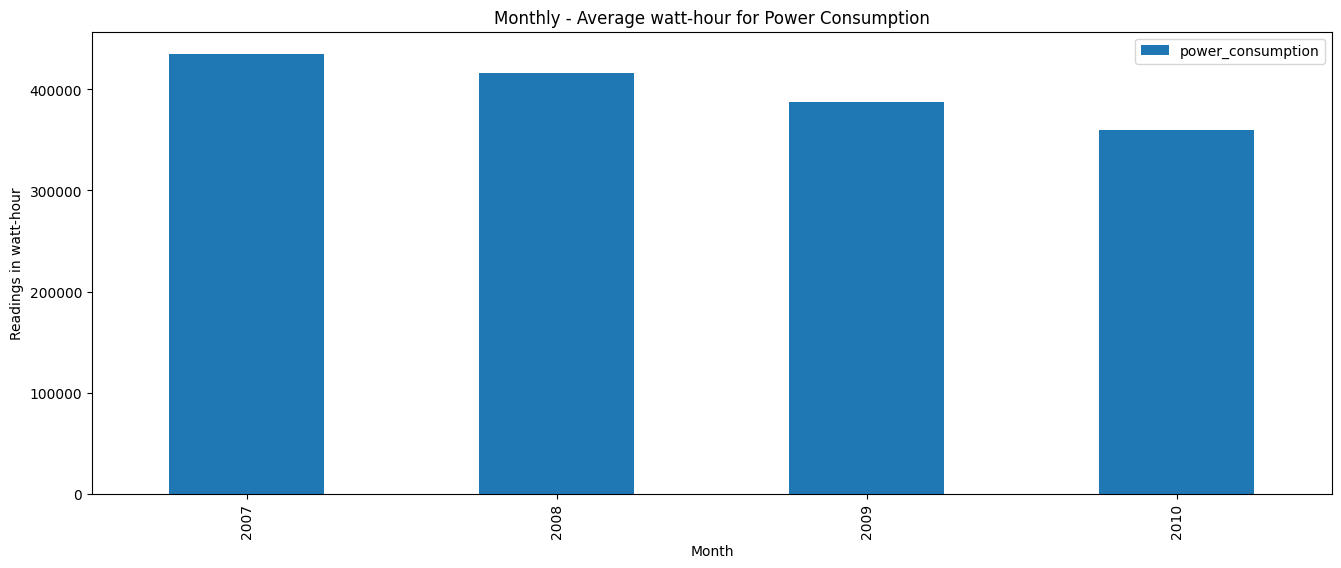

In [ ]:
df_power_consumption.groupby(df_power_consumption.index.year).mean().plot(kind="bar",xlabel='Month',ylabel='Readings in watt-hour',title="Monthly - Average watt-hour for Power Consumption", figsize=(16,6))

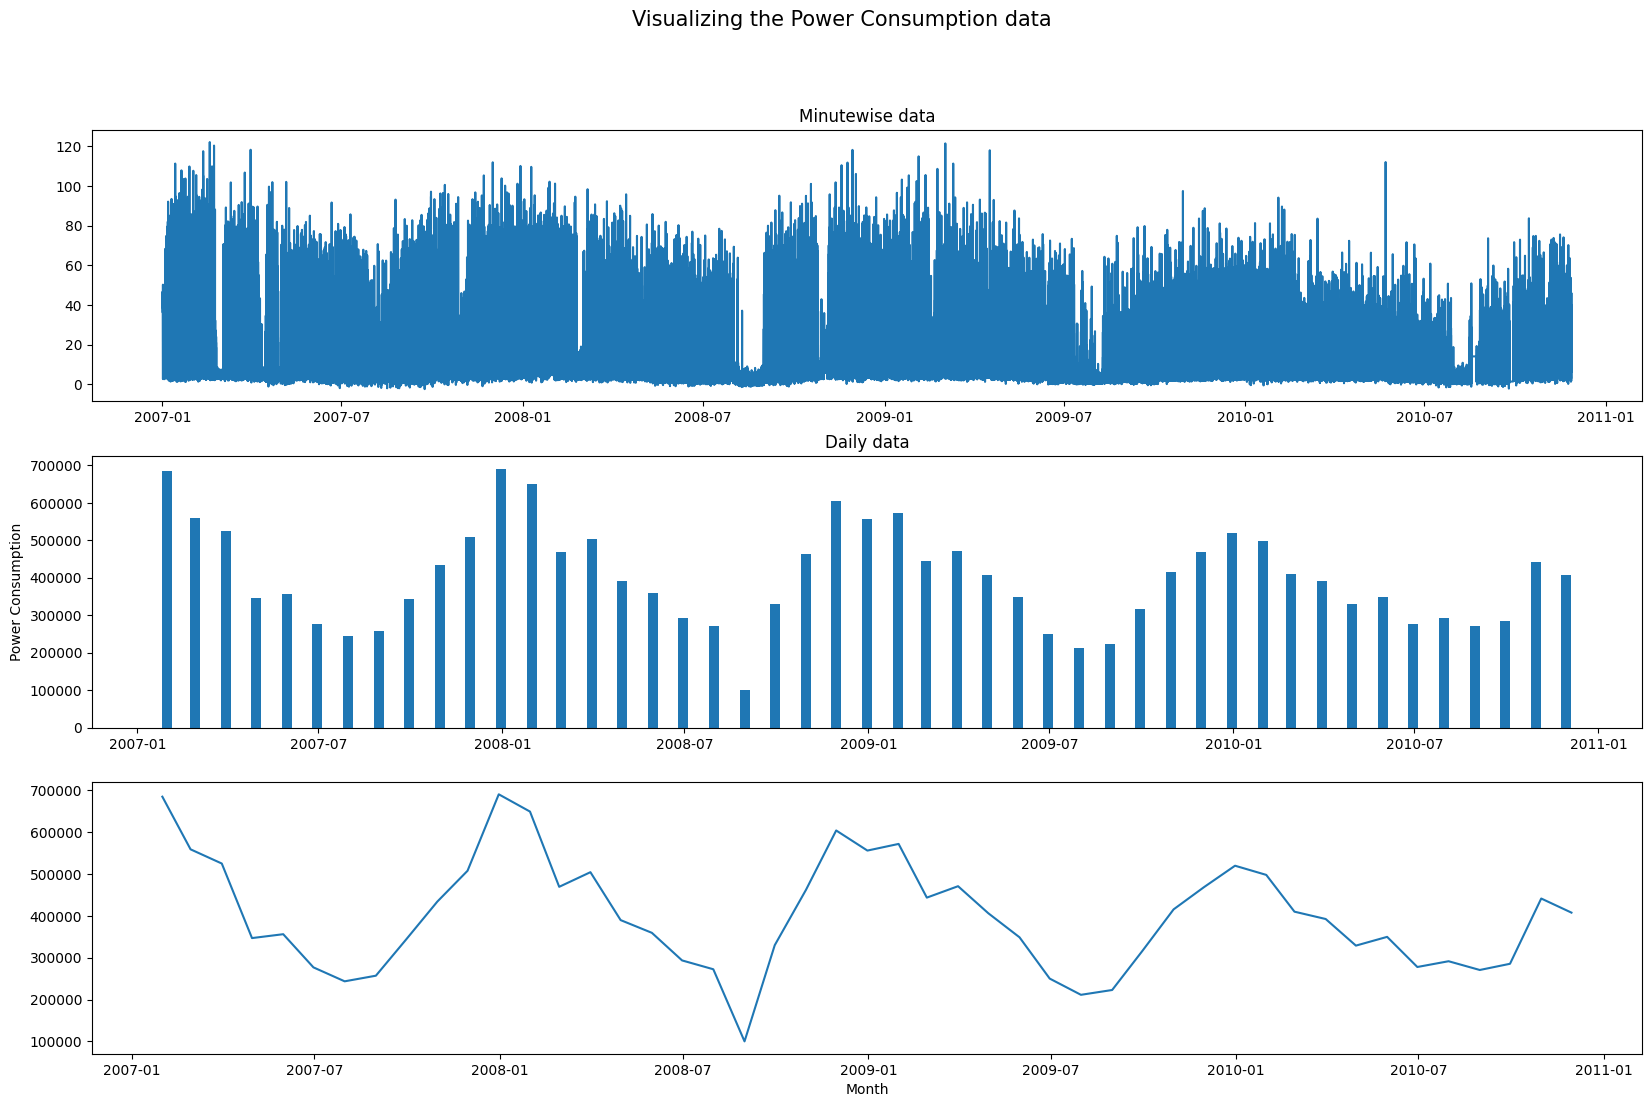

In [ ]:
fig , axs = plt.subplots(3,1,figsize=(20,12))
axs[0].plot(data_subset['power_consumption'])
axs[1].bar(data_monthly.index,data_monthly['power_consumption'], width=10)
axs[2].plot(data_monthly['power_consumption'])
axs[2].set_xlabel("Month")
axs[1].set_ylabel("Power Consumption")
axs[0].set_title("Minutewise data")
axs[1].set_title("Daily data")
plt.suptitle("Visualizing the Power Consumption data", size=15)
plt.show()

In [ ]:
import calendar

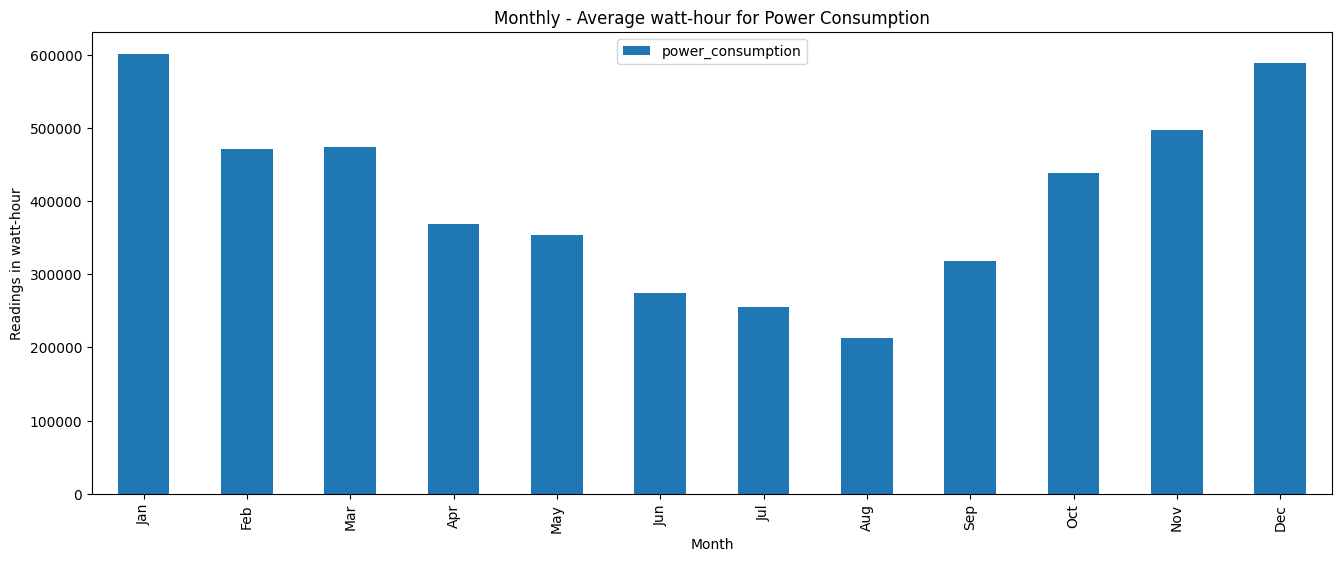

In [ ]:
ax=df_power_consumption.groupby(df_power_consumption.index.month).mean().plot(kind="bar",xlabel='Month',
ylabel='Readings in watt-hour',title="Monthly - Average watt-hour for Power Consumption", figsize=(16,6))
ax.set_xticklabels(calendar.month_abbr[x] for x in range(1,13))
plt.show()

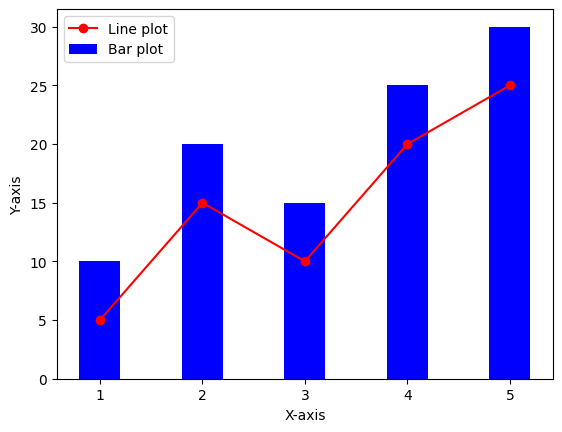

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create some sample data
x = np.array([1, 2, 3, 4, 5])
y1 = np.array([10, 20, 15, 25, 30])
y2 = np.array([5, 15, 10, 20, 25])

# Create the figure and axes objects
fig, ax = plt.subplots()

# Create the bar plot
ax.bar(x, y1, color='blue', width=0.4, label='Bar plot')

# Create the line plot
ax.plot(x, y2, color='red', marker='o', label='Line plot')

# Set the x-axis label
ax.set_xlabel('X-axis')

# Set the y-axis label
ax.set_ylabel('Y-axis')

# Add a legend
ax.legend()

# Show the plot
plt.show()








([], [])

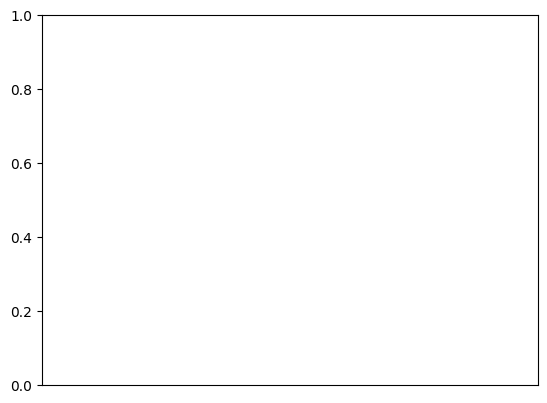

In [ ]:

plt.xticks([])

In [ ]:
data_hourly = data_subset.groupby(pd.Grouper(key='exact_time_DT',freq='H')).sum()
data_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,power_consumption
exact_time_DT,,,,,,,,
2007-01-01 00:00:00,153.038,6.768,14481.68,631.8,0.0,35.0,0.0,2515.633333
2007-01-01 01:00:00,151.404,4.298,14465.79,626.6,0.0,0.0,0.0,2523.400000
2007-01-01 02:00:00,154.940,6.400,14592.01,632.4,0.0,20.0,0.0,2562.333333
2007-01-01 03:00:00,152.500,5.406,14595.94,624.0,0.0,16.0,0.0,2525.666667
2007-01-01 04:00:00,148.544,5.290,14547.37,606.6,0.0,0.0,0.0,2475.733333


<Axes: xlabel='exact_time_DT'>

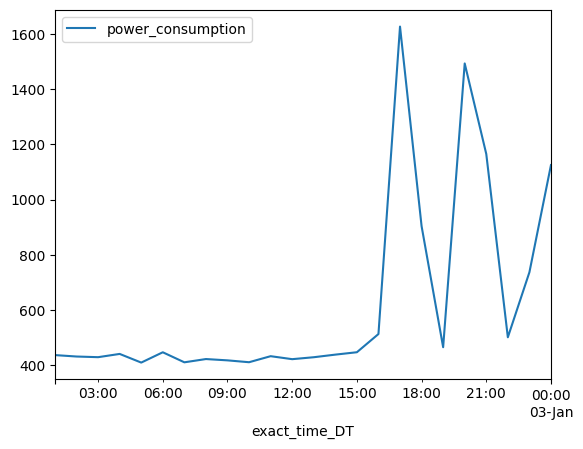

In [ ]:
data_hourly[["power_consumption"]][25:49].plot(kind='line')

In [ ]:
import statsmodels.api as sm

In [ ]:
model = sm.tsa.arima.ARIMA(data_monthly['power_consumption'], order=(3,0,2))
results=model.fit()

In [ ]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:      power_consumption   No. Observations:                   47
Model:                 ARIMA(3, 0, 2)   Log Likelihood                -589.995
Date:                Tue, 18 Apr 2023   AIC                           1193.990
Time:                        12:59:16   BIC                           1206.941
Sample:                    01-31-2007   HQIC                          1198.863
                         - 11-30-2010                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.003e+05   1.17e+04     34.137      0.000    3.77e+05    4.23e+05
ar.L1          0.8026      0.269      2.987      0.003       0.276       1.329
ar.L2          0.4614      0.413      1.117      0.264      -0.349       1.271
ar.L3         -0.7377      0.211     -3.494      0.000      -1.151      -0.324
ma.L1         -0.1331      0.383     -0.347      0.728      -0.884       0.618
ma.L2         -0.4076      0.283     -1.441      0.150      -0.962       0.147
sigma2      4.485e+09      0.029   1.54e+11      0.000    4.49e+09    4.49e+09
===================================================================================
Ljung-Box (L1) (Q):                   0.46   Jarque-Bera (JB):                 0.74
Prob(Q):                              0.50   Prob(JB):                         0.69
Heteroskedasticity (H):               0.41   Skew:                             0.23
Prob(H) (two-sided):                  0.08   Kurtosis:                         3.42
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.2e+27. Standard errors may be unstable.
"""

In [ ]:
from pandas.tseries.offsets import DateOffset
future_dates=[data_monthly.index[-1]+ DateOffset(months=x)for x in range(0,48)]

In [ ]:
future_datest_df=pd.DataFrame(index=future_dates[1:],columns=data_monthly.columns)

In [ ]:
future_df=pd.concat([data_monthly,future_datest_df])


In [ ]:
future_df.tail(50)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,power_consumption
2010-09-30,37074.026,5025.038,10426323.08,157538.6,36865.0,32508.0,263098.0,285429.433333
2010-10-31,51935.398,6140.780,10809991.52,218251.0,48199.0,60252.0,315670.0,441468.966667
2010-11-30,44598.388,4128.708,8970019.70,188465.4,46162.0,42282.0,247113.0,407749.466667
2010-12-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-03-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-05-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

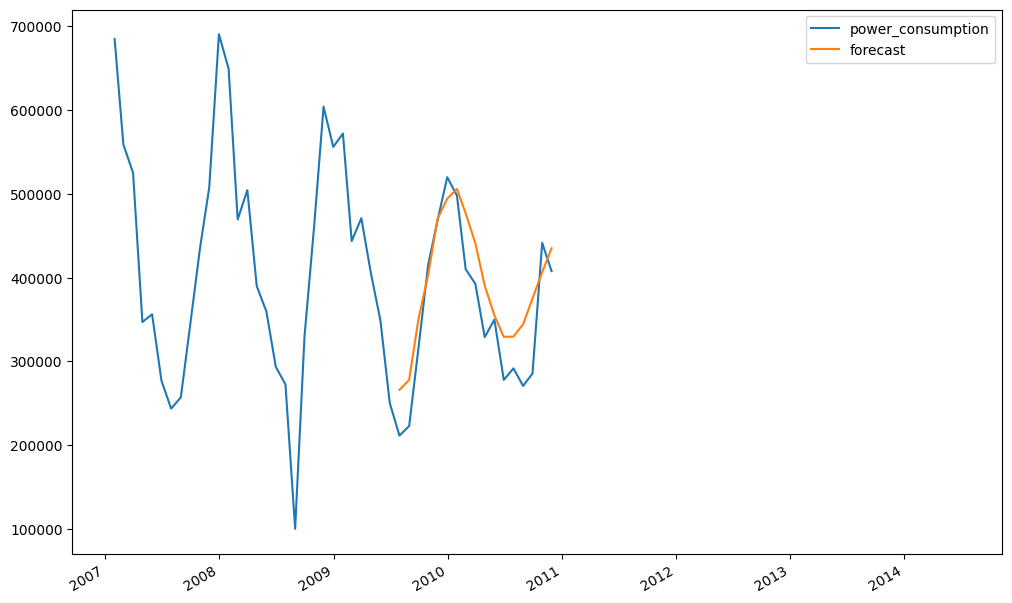

In [ ]:
future_df['forecast'] = results.predict(start = 30, end = 90, dynamic= True)
future_df[['power_consumption', 'forecast']].plot(figsize=(12, 8))

In [ ]:
ARIMA_model = pm.auto_arima(data_daily["power_consumption"], start_p=8, start_q=8,
                         test='adf',
                         max_p=15, max_q=15,
                         m=1, #12 is the frequncy of the cycle
                         start_P=0,
                         seasonal=False, #set to seasonal
                         d=None,
                         #D=1, #order of the seasonal differencing
                         trace=False,
                         error_action='ignore',
                         suppress_warnings=True,
                         stepwise=True)

In [ ]:
ARIMA_model.get_params()

{'maxiter': 50,
 'method': 'lbfgs',
 'order': (9, 0, 8),
 'out_of_sample_size': 0,
 'scoring': 'mse',
 'scoring_args': {},
 'seasonal_order': (0, 0, 0, 0),
 'start_params': None,
 'suppress_warnings': True,
 'trend': None,
 'with_intercept': False}

In [ ]:
def arima_forecast(ARIMA_model, periods=365):
    # Forecast
    n_periods = periods
    train = data_daily[(data_daily.index.get_level_values(0)>='2007-01-01') & (data_daily.index.get_level_values(0)<='2009-12-31')]
    test = data_daily[(data_daily.index.get_level_values(0)>='2010-01-01')]
    fitted, confint = ARIMA_model.predict(test.shape[0], return_conf_int=True) # training prediction values
    fc_index = pd.to_datetime(test.index.get_level_values(0))
    index_of_fc = fc_index

    fitted_1, confint_1 = ARIMA_model.predict(n_periods=n_periods, # prediction/forecast values
                                            return_conf_int=True)
    index_of_fc_1 = pd.date_range(data_daily.index[-2] + pd.DateOffset(days=1), periods = n_periods, freq='D')

    # make series for plotting purpose
    fitted_series = pd.Series(fitted.values, index=index_of_fc)
    lower_series = pd.Series(confint[:, 0], index=index_of_fc)
    upper_series = pd.Series(confint[:, 1], index=index_of_fc)

    fitted_series_1 = pd.Series(fitted_1.values, index=index_of_fc_1)
    lower_series_1 = pd.Series(confint_1[:, 0], index=index_of_fc_1)
    upper_series_1 = pd.Series(confint_1[:, 1], index=index_of_fc_1)

    # Plot
    plt.figure(figsize=(15,7))
    plt.plot(data_daily["power_consumption"], color='#1f76b4',label='Train/Test')
    plt.plot(fitted_series, color='darkgreen',label='Test_pred')
    plt.plot(fitted_series_1,color = 'red',label='next 1 year forecast')
    plt.title("ARIMA - Forecast of Power Consumption")
    plt.fill_between(lower_series_1.index,
                    lower_series_1,
                    upper_series_1,
                    color='k', alpha=.15)
    plt.xlabel('Year-Month')
    plt.ylabel('Power Consumption')
    plt.legend(loc="best")
    plt.show()
    return test['power_consumption'], fitted_series

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

/usr/local/lib/python3.9/dist-packages/statsmodels/graphics/tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


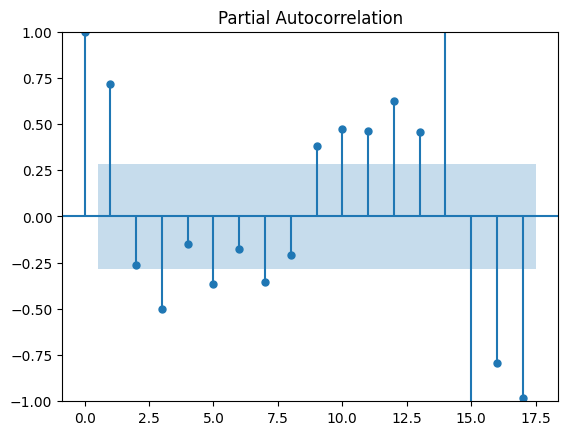

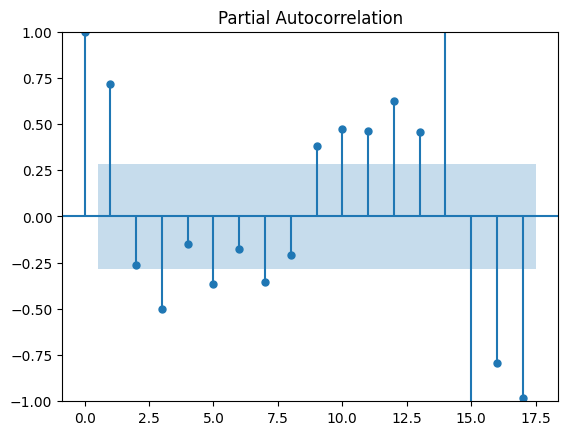

In [ ]:
plot_pacf(data_monthly["power_consumption"])

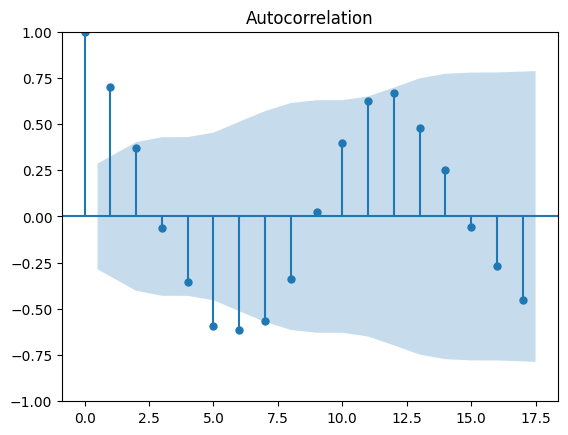

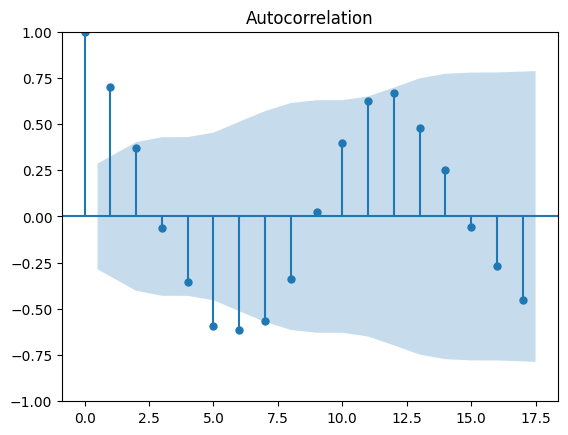

In [ ]:
plot_acf(data_monthly["power_consumption"])

In [ ]:
model1=SARIMAX(data_monthly["power_consumption"],order=(0, 1, 1), seasonal_order=(1, 1, 1, 12))
result1=model1.fit()

/usr/local/lib/python3.9/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [ ]:
print(result1.summary())

                                     SARIMAX Results                                      
Dep. Variable:                  power_consumption   No. Observations:                   47
Model:             SARIMAX(0, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -429.465
Date:                            Tue, 18 Apr 2023   AIC                            866.929
Time:                                    13:01:52   BIC                            873.035
Sample:                                01-31-2007   HQIC                           869.011
                                     - 11-30-2010                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0056      0.111      0.050      0.960      -0.212       0.223
ar.S.L12       0.3990      0.239   

In [ ]:
model2=SARIMAX(data_monthly["power_consumption"],order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
result2=model2.fit()

/usr/local/lib/python3.9/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [ ]:
print(result2.summary())

                                     SARIMAX Results                                      
Dep. Variable:                  power_consumption   No. Observations:                   47
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -428.940
Date:                            Tue, 18 Apr 2023   AIC                            867.879
Time:                                    13:01:53   BIC                            875.511
Sample:                                01-31-2007   HQIC                           870.482
                                     - 11-30-2010                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6475      0.463      1.398      0.162      -0.260       1.555
ma.L1         -0.7492      0.424   

In [ ]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.metrics import r2_score
import seaborn as sns
sns.set_context("paper", font_scale=1.3)
sns.set_style('white')
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import *
from keras.callbacks import EarlyStopping

In [ ]:
len(data['power_consumption'])

2075259

In [ ]:
dataset = data['power_consumption'].values.astype('float32')
#Reshape the numpy array into a 2D array with 1 column

dataset = np.reshape(dataset, (-1, 1))
#Create an instance of the MinMaxScaler class to scale the values between 0 and 1

scaler = MinMaxScaler(feature_range=(0, 1))
#Fit the MinMaxScaler to the transformed data and transform the values

dataset = scaler.fit_transform(dataset)
#Split the transformed data into a training set (80%) and a test set (20%)

train_size = int(len(dataset) * 0.80)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

In [ ]:
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

In [ ]:
look_back = 30
X_train, Y_train = create_dataset(train, look_back)
X_test, Y_test = create_dataset(test, look_back)

In [ ]:
X_train.shape, Y_train.shape

((1660176, 30), (1660176,))

In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

In [ ]:
model = Sequential()

# Adding the first layer with 100 LSTM units and input shape of the data
model.add(LSTM(100, input_shape=(X_train.shape[1], X_train.shape[2])))

# Adding a dropout layer to avoid overfitting
model.add(Dropout(0.2))

# Adding a dense layer with 1 unit to make predictions
model.add(Dense(1))

# Compiling the model with mean squared error as the loss function and using Adam optimizer
model.compile(loss='mean_squared_error', optimizer='adam')

# Fitting the model on training data and using early stopping to avoid overfitting
history = model.fit(X_train, Y_train, epochs=20, batch_size=1240, validation_data=(X_test, Y_test),
                    callbacks=[EarlyStopping(monitor='val_loss', patience=4)], verbose=None, shuffle=False)

# Displaying a summary of the model
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 100)               52400     
                                                                 
 dropout (Dropout)           (None, 100)               0         
                                                                 
 dense (Dense)               (None, 1)                 101       
                                                                 
Total params: 52,501
Trainable params: 52,501
Non-trainable params: 0
_________________________________________________________________


In [ ]:
import pickle
from tqdm import tqdm

In [ ]:
f=open("/content/drive/MyDrive/"+"tsa_model", 'wb')
pickle.dump(model, f)
f.close()

In [ ]:
f=open("/content/drive/MyDrive/"+"tsa_model", 'rb')
model=pickle.load(f)
f.close()

In [ ]:
scaler.inverse_transform(model.predict(np.array([X_test[0]])))

1/1 [==============================] - 0s 30ms/step


array([[6.2127895]], dtype=float32)

In [ ]:
l1=model.predict(np.array([X_test[0]]))

1/1 [==============================] - 0s 25ms/step


In [ ]:
model.predict(np.array([[list(dataset[-30:].flatten())]]))

1/1 [==============================] - 0s 89ms/step


array([[0.14143787]], dtype=float32)

In [ ]:
lo=list(dataset[-30:].flatten())

In [ ]:
scaler.inverse_transform(l1)[0][0]

6.2127895

In [ ]:
input1=list(dataset[-30:].flatten())
forecast=[]
for i in tqdm(range(5000)):
  scaled_fore = model.predict(np.array([[input1[-30:]]]))
  input1.append(scaled_fore[0][0])
  fore=np.array([[scaled_fore[0][0]]])
  forecast.append(scaler.inverse_transform(fore))

  0%|          | 0/5000 [00:00<?, ?it/s]

1/1 [==============================] - 1s 862ms/step


  0%|          | 1/5000 [00:01<1:25:29,  1.03s/it]

1/1 [==============================] - 0s 71ms/step


  0%|          | 2/5000 [00:01<46:12,  1.80it/s]  

...

100%|█████████▉| 4998/5000 [08:27<00:00,  7.68it/s]

1/1 [==============================] - 0s 42ms/step


100%|█████████▉| 4999/5000 [08:27<00:00,  8.10it/s]

1/1 [==============================] - 0s 33ms/step


100%|██████████| 5000/5000 [08:28<00:00,  9.84it/s]


In [ ]:
forecast1=[ i[0][0] for i in forecast]

In [ ]:
forecast1 = []

[array([[15.595613]], dtype=float32),
 array([[15.710155]], dtype=float32),
 array([[15.836183]], dtype=float32),
 array([[15.880962]], dtype=float32),
 array([[15.977677]], dtype=float32),
 array([[16.08997]], dtype=float32),
 array([[16.13386]], dtype=float32),
 array([[16.21014]], dtype=float32),
 array([[16.306215]], dtype=float32),
 array([[16.351576]], dtype=float32)]

In [ ]:
Y_test.shape[1]

415021

In [ ]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)
# invert predictions
train_predict = scaler.inverse_transform(train_predict)
Y_train = scaler.inverse_transform([Y_train])
test_predict = scaler.inverse_transform(test_predict)
Y_test = scaler.inverse_transform([Y_test])

12970/12970 [==============================] - 23s 2ms/step


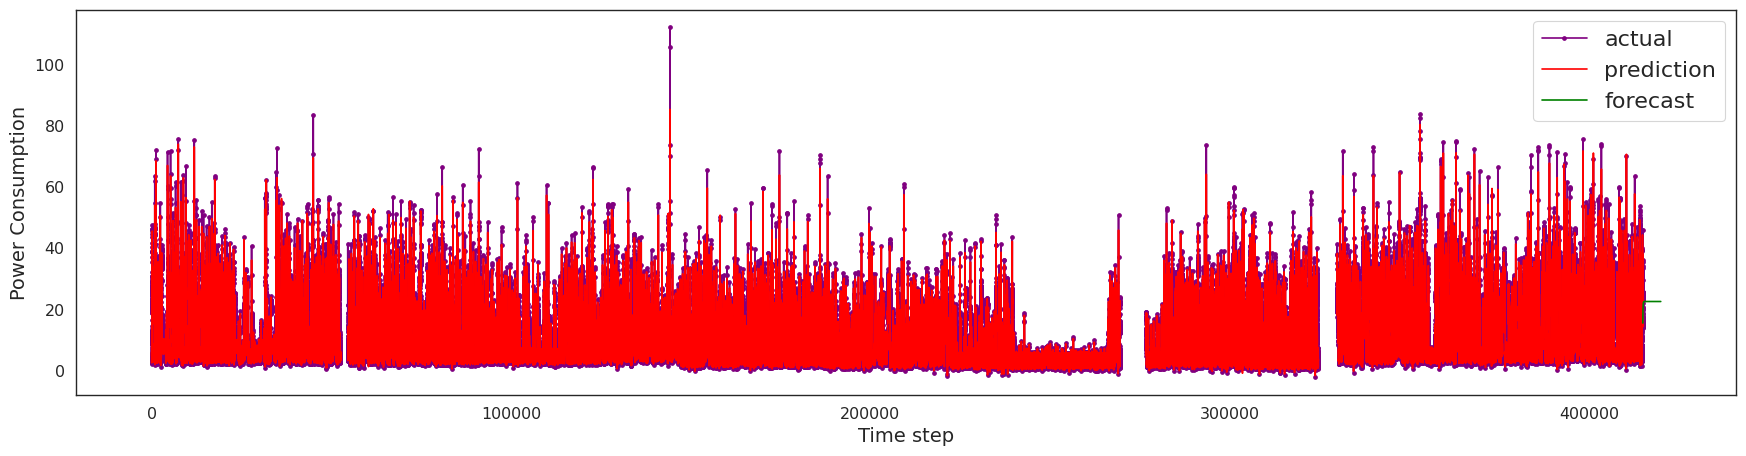

In [ ]:
aa=[x for x in range(Y_test.shape[1])]
# Creating a figure object with desired figure size
plt.figure(figsize=(20,5))

# Plotting the actual values in blue with a dot marker
plt.plot(aa, Y_test[0][:], marker='.', label="actual", color='purple')

# Plotting the predicted values in green with a solid line
plt.plot(aa, test_predict[:,0][:], '-', label="prediction", color='red')
plt.plot(list(range(415022,420022)),forecast1, label="forecast", color="green")

# Removing the top spines
#sns.despine(top=True)

# Adjusting the subplot location
plt.subplots_adjust(left=0.07)

# Labeling the y-axis
plt.ylabel('Power Consumption', size=14)

# Labeling the x-axis
plt.xlabel('Time step', size=14)

# Adding a legend with font size of 15
plt.legend(fontsize=16)

# Display the plot
plt.show()

In [ ]:
X_train[0]

array([[0.4296568 , 0.5873723 , 0.573487  , 0.5831805 , 0.35761067,
        0.33062616, 0.36232644, 0.36206448, 0.3578727 , 0.35708672,
        0.4600472 , 0.5863243 , 0.5695572 , 0.5596018 , 0.40843594,
        0.32853028, 0.31359708, 0.33455595, 0.30521354, 0.37359184,
        0.66518205, 0.8946817 , 0.813466  , 0.56300753, 0.47131255,
        0.31071526, 0.30914333, 0.30809537, 0.31202516, 0.30154574]],
      dtype=float32)

In [ ]:
print('Train Mean Absolute Error:', mean_absolute_error(Y_train[0], train_predict[:,0]))
print('\nTrain Root Mean Squared Error:',np.sqrt(mean_squared_error(Y_train[0], train_predict[:,0])))
print('\nTest Mean Absolute Error:', mean_absolute_error(Y_test[0], test_predict[:,0]))
print('\nTest Root Mean Squared Error:',np.sqrt(mean_squared_error(Y_test[0], test_predict[:,0])))
print('\nR2 score:',r2_score(Y_test[0], test_predict[:,0]))

Train Mean Absolute Error: 1.2241271541889627

Train Root Mean Squared Error: 2.9263701267319977

Test Mean Absolute Error: 1.1119163163604333

Test Root Mean Squared Error: 2.157108086066503

R2 score: 0.9011431091034725
